In [1]:
%load_ext autoreload
%autoreload 2

# Prova con 400 epoche e training set con 5000 x 3 dati: ottimo risultato sulla funzione semplice

Todo: provare con funzione coi seni, magari espandendo la targetnetwork

In [2]:
import os

# CPU fallback (if GPU is not available)
if 'JAX_PLATFORMS' not in os.environ:
    try:
        from jax import devices
        if not any(d.platform == 'gpu' for d in devices()):
            os.environ['JAX_PLATFORMS'] = 'cpu'
    except Exception:
        os.environ['JAX_PLATFORMS'] = 'cpu'

# Import necessary libraries
import jax.numpy as jnp
import jax.random as random
import optax
from data import Dataset, JaxDataLoader
from models import MLP
from training import assign_parameters, EarlyStopping
from utils import variables_generator
from losses import CustomLoss, RRMSE, MAE, L2Loss
from flax import nnx
import optax
import matplotlib.pyplot as plt
from training import train_model
from inference import test_model

2025-10-18 00:42:35.479376: E external/xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


ImportError: cannot import name 'RRMSE' from 'losses.losses' (/home/riccardorota/PACS/PACSproject/losses/losses.py)

In [18]:
f_to_learn = lambda mu, l, k, x: jnp.exp(l*x) + mu*x + k*x**2

# DATASET GENERATION
key = random.key(0)
mu_domain = (-2, 2)
l_domain = (0, 1)
k_domain = (-2, 2)
x_domain = (-1, 1)
N = 1000
n_realizations = 10
mu, l, k, x = variables_generator(N=N, n_realizations=n_realizations, var_names=['x'], var_domains=[x_domain], hypervar_domains=[mu_domain, l_domain, k_domain], hypervar_names=['mu', 'l', 'k'], key=key).values()
y = f_to_learn(mu, l, k, x)
X = jnp.stack([mu, l, k, x], axis=1)

# DATASET SPLIT AND DATALOADERS CREATION
split_idx1, split_idx2 = int(N*n_realizations * 0.8), int(N*n_realizations * 0.9)
X_train, X_val, X_test = X[:split_idx1], X[split_idx1:split_idx2], X[split_idx2:]
y_train, y_val, y_test = y[:split_idx1], y[split_idx1:split_idx2], y[split_idx2:]

# Create datasets and dataloaders
batch_size = 1024
dataset_train = Dataset(vars=X_train[:, 3], hypervars=X_train[:, :3], labels=y_train)
dataset_val = Dataset(vars=X_val[:, 3], hypervars=X_val[:, :3], labels=y_val)
dataset_test = Dataset(vars=X_test[:, 3], hypervars=X_test[:, :3], labels=y_test)

train_dataloader = JaxDataLoader(dataset_train, batch_size=batch_size, shuffle=True)
val_dataloader = JaxDataLoader(dataset_val, batch_size=batch_size, shuffle=False)
test_dataloader = JaxDataLoader(dataset_test, batch_size=batch_size, shuffle=False)

In [8]:
# Model definition
run_id='run_9'
targetnetwork = MLP(num_neurons=[1, 8, 8, 1], rngs=nnx.Rngs(0), activation_functions=[nnx.tanh, nnx.tanh])
num_params = targetnetwork.num_parameters()
hypernetwork = MLP(num_neurons=[3, 32, 32, 128, num_params], rngs=nnx.Rngs(0), activation_functions=[nnx.relu, nnx.relu, nnx.relu])

# Loss, metrics and epochs
criterion = l2_loss #criterion = CustomLoss(l2_penalty_weight=1e-4)
metrics = {'RRMSE': RRMSE, 'MAE': MAE}
epochs = 10000

# Epochs, scheduler, optimizer and early stopping
early_stopping = EarlyStopping(patience=1000, min_delta=1e-6)
lr_schedule = optax.schedules.cosine_decay_schedule(init_value=1e-2, decay_steps=10000, alpha=1e-6) #SE USIAMO QUESTO METTERAI DECAY LENTO, IO PROVEREI ALTRI SCHEDULER
schedule_optimizer = nnx.Optimizer(hypernetwork, optax.adam(learning_rate=lr_schedule))

accumulation_size = len(val_dataloader)
plateau_scheduler = optax.contrib.reduce_on_plateau(factor=0.2, patience=100, accumulation_size=accumulation_size)
plateau_optimizer = optax.chain(
    optax.adam(learning_rate=1e-2),
    plateau_scheduler
) 
nnx_plateau_optimizer = nnx.Optimizer(hypernetwork, plateau_optimizer)

# Training
log_file_path = "experiment_outputs/" + run_id + ".txt"

# if os.path.exists(log_file_path):
#     raise FileExistsError(f"Log file already exists: {log_file_path}. Change the run_id to avoid overwriting.")

history = train_model(
        hypernetwork=hypernetwork,
        targetnetwork=targetnetwork,
        train_loader=train_dataloader,
        val_loader=val_dataloader,
        optimizer=nnx_plateau_optimizer, #plateau_optimizer,
        num_epochs=epochs,
        criterion=criterion,
        metrics=metrics,
        early_stopping_metric='RRMSE',
        early_stopping=early_stopping,
        log_file_path=log_file_path
)

Epoch 10000/10000 - Train: loss: 0.0000, RRMSE: 0.0013, MAE: 0.0014 - Val: loss: 0.0000, RRMSE: 0.0017, MAE: 0.0017 - LR multiplier: 0.0000: 100%|██████████| 10000/10000 [15:25<00:00, 10.80it/s]


In [9]:
test_metrics = test_model(
    hypernetwork=hypernetwork,
    targetnetwork=targetnetwork,
    loader=test_dataloader,
    metrics=(RRMSE, MAE),
    )
print("Test set metrics:", test_metrics)

Testing: 100%|██████████| 10/10 [00:04<00:00,  2.22it/s]

Test set metrics: {'RRMSE': Array(0.00166352, dtype=float32), 'MAE': Array(0.0016249, dtype=float32)}


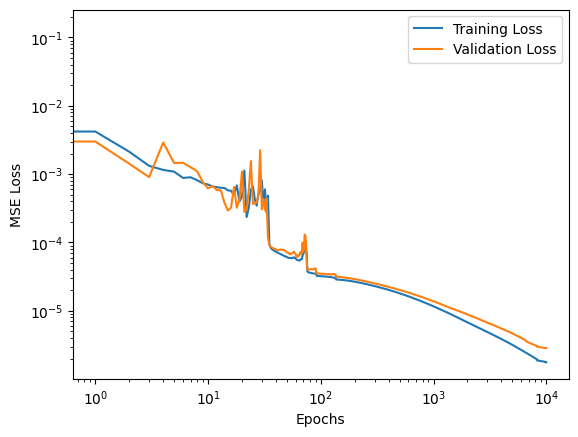

In [12]:
training_loss_history = [m['loss'] for m in history['train_results']]
val_loss_history = [m['loss'] for m in history['val_results']]
plt.loglog(range(len(training_loss_history)), training_loss_history, label='Training Loss')
plt.loglog(range(len(val_loss_history)), val_loss_history, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

/tmp/ipykernel_25918/3476380160.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


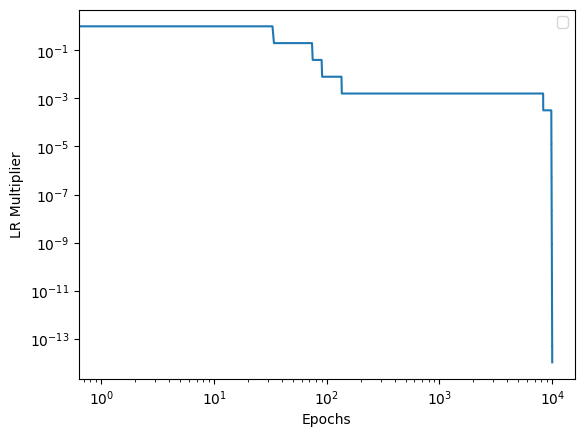

In [15]:
lr_history = history['lrs']
plt.loglog(range(len(lr_history)), lr_history)
plt.xlabel('Epochs')
plt.ylabel('LR Multiplier')
plt.legend()
plt.show()

In [13]:
# PLOTTING RESULTS ON SOME EXAMPLES
N_example = 4
key_example = random.key(1)  # DON'T PUT 0 TO AVOID DATA LEAKAGE
mu_example, l_example, k_example = variables_generator(N = N_example, var_domains = [mu_domain, l_domain, k_domain], key = key_example).values()

example_hypervars = jnp.stack([mu_example, l_example, k_example], axis=1)
particular_hypervars= jnp.array([[0.0, 1.0, 0.0], [0.0, 0.0, 1.0]])
example_hypervars = jnp.vstack([example_hypervars, particular_hypervars]) 

x_vector = jnp.linspace(-1, 1, 101)
x_vector = x_vector[:,None]

In [ ]:
plots_data = []

for hypervars in example_hypervars:
    w = hypernetwork(hypervars)  # get the weights from the hypernetwork
    targetnetwork = assign_parameters(targetnetwork, w)  # assign the weights to the target network
    mu, l, k = hypervars 
    y_pred = targetnetwork(x_vector)  # predicted function values
    y_vector = jnp.array([f_to_learn(mu, l, k, x) for x in x_vector])  # true function values
    
    plots_data.append({ #store data for plotting
        'x': x_vector,
        'y_pred': y_pred,
        'y_true': y_vector,
        'params': (mu, l, k)
    })

: 

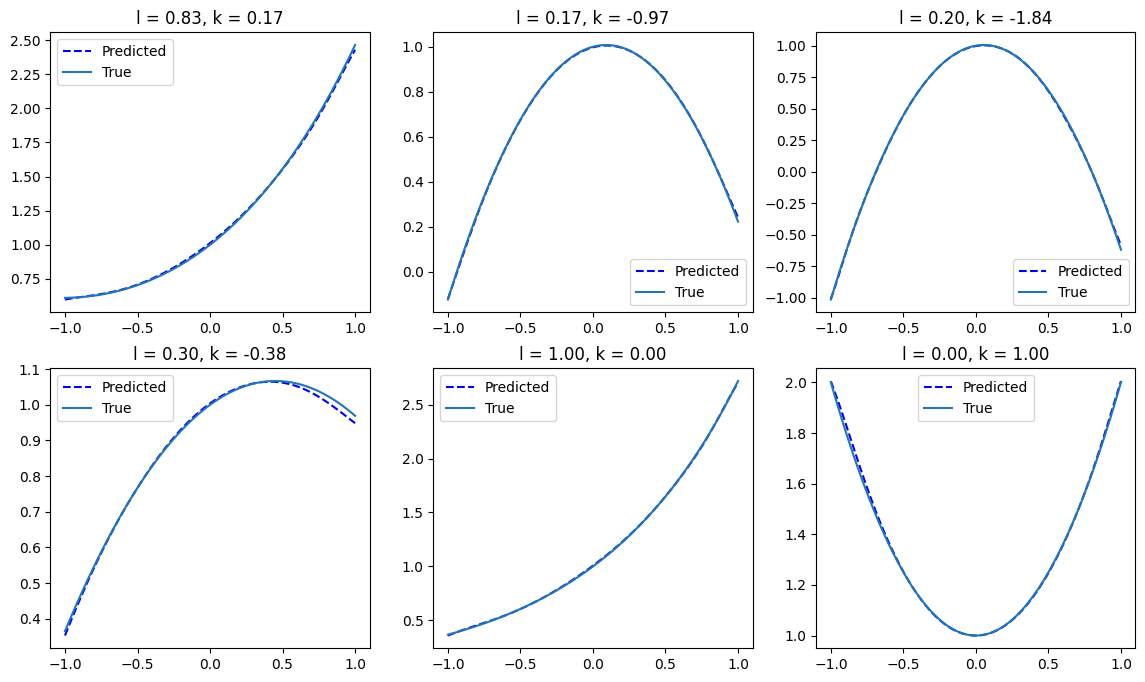

: 

In [ ]:
num_cols = 3
fig, ax = plt.subplots(2,num_cols, figsize=(14, 8))
for i, data in enumerate(plots_data[0:6]):
    ax[i//num_cols, i%num_cols].plot(data['x'], data['y_pred'], '--b')
    ax[i//num_cols, i%num_cols].plot(data['x'], data['y_true'])
    ax[i//num_cols, i%num_cols].legend(['Predicted', 'True'])
    ax[i//num_cols, i%num_cols].set_title(f'l = {data["params"][1]:.2f}, k = {data["params"][2]:.2f}')
plt.show()